In [30]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

num_classes = 4
steps = [1, 2, 3, 4]
num_steps = 4

baseline_metrics = {c: [np.nan]*num_steps for c in range(num_classes)}
poisoned_metrics = {c: [np.nan]*num_steps for c in range(num_classes)}

In [31]:
# Creiamo un dataset 
def generate_data(num_samples, num_features, label):
    # Genera dati per una classe specifica

    X = np.random.normal(loc=label, scale=1.0, size=(num_samples, num_features))
    y = np.full(num_samples, label)
    return X,y

In [32]:
NUM_FEATURES = 20
SAMPLES_PER_CLASS = 1000

X_all = []
y_all = []

for label in range(4):
    X, y = generate_data(SAMPLES_PER_CLASS, NUM_FEATURES, label)
    X_all.append(X)
    y_all.append(y)

X_all = np.vstack(X_all) # metto tutti dati divisi per classe uno dopo l'altro
y_all = np.hstack(y_all) # metto tutti i dati uno accanto all'altro divisi per classe

In [33]:
# Divido i dati per classe, le classi rappresentano il flusso di dati: Normal, DoS, Probe, BruteForce

In [34]:
class_data = {}

for label in range(4):
    X = X_all[y_all == label]
    y = y_all[y_all == label]

    class_data[label] = train_test_split(X,y,test_size=0.3,random_state=42)

# class_data[label][0] -> X_train
# class_data[label][0] -> X_test

In [35]:
# Creo un modello neurale semplice

class IDSModel(nn.Module):
    # creaiamo una rete neurale personalizzata, definiamo un Multi-Layer Perceptron 
    # per la classificazione
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(     # Modello sequenziale, l'output di un layer va direttamente all'altro
            nn.Linear(input_dim, 64), # Layer1: trasforma l'input in uno spazio latente di 64 neuroni
            nn.ReLU(),                # Layer2: introduce non linearità, senza il modello sarebbe solo una regressione lineare
            nn.Linear(64, 64),        # Layer3: permette di apprendere pattern più complessi 
            nn.ReLU(),                # Layer4: rafforza le capacità di separazione lineare
            nn.Linear(64, num_classes)# Layer5: output, produce una probabilità per ogni tipo di traffico
        )

    def forward(self, x):             # definisce come i dati attraversano la rete
        return self.net(x)            # richiama Sequential


In [36]:
# Definizione di una funzione di train generica
def train(model, X, y, epochs=10, lr=0.001):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr) # Adam: adatta automaticamente il learning rate
    criterion = nn.CrossEntropyLoss()                 # Definizione della funzione di perdita

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    for _ in range(epochs):            # Simulazione di un apprendimento reale
        optimizer.zero_grad()          # PyTorch accumula i gradienti che vanno azzerati
        outputs = model(X)             # X -> rete -> logits (output)
        loss = criterion(outputs, y)   # Calcolo quanto sbaglia sulle classi attuali
        loss.backward()                # Calcolo del gradient loss, rispetto a tutti i pesi
        optimizer.step()               # Aggiornamento dei pesi


In [37]:
def evaluate(model, X, y):
    model.eval()
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    if X.dim() == 1:
        X = X.view(-1, NUM_FEATURES)

    with torch.no_grad():
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

    return accuracy_score(y.numpy(), preds.numpy())


In [39]:
# BASELINE: Class Incremental Learning (senza attacco)
model = IDSModel(NUM_FEATURES, 4)

seen_classes = []

for step in range(4):
    print(f"\n=== Training step {step+1} ===")
    seen_classes.append(step)

    X_list, y_list = [], []

    for c in seen_classes:
        X_tr, X_te, y_tr, y_te = class_data[c]
        X_list.append(X_tr)
        y_list.append(y_tr)

    X_train = np.vstack(X_list)
    y_train = np.hstack(y_list)

    print("TRAIN SHAPES:", X_train.shape, y_train.shape)

    train(model, X_train, y_train)

    for c in seen_classes:
        acc = evaluate(model, class_data[c][1], class_data[c][3])
        baseline_metrics[c][step] = acc
        print(f"Accuracy on class {c}: {acc:.3f}")

print(baseline_metrics)


=== Training step 1 ===
TRAIN SHAPES: (700, 20) (700,)
Accuracy on class 0: 1.000

=== Training step 2 ===
TRAIN SHAPES: (1400, 20) (1400,)
Accuracy on class 0: 0.983
Accuracy on class 1: 0.437

=== Training step 3 ===
TRAIN SHAPES: (2100, 20) (2100,)
Accuracy on class 0: 1.000
Accuracy on class 1: 0.267
Accuracy on class 2: 0.000

=== Training step 4 ===
TRAIN SHAPES: (2800, 20) (2800,)
Accuracy on class 0: 0.997
Accuracy on class 1: 0.393
Accuracy on class 2: 0.693
Accuracy on class 3: 0.000
{0: [1.0, 0.9833333333333333, 1.0, 0.9966666666666667], 1: [nan, 0.43666666666666665, 0.26666666666666666, 0.3933333333333333], 2: [nan, nan, 0.0, 0.6933333333333334], 3: [nan, nan, nan, 0.0]}


In [20]:
# Stability - Plasticity Dilemma
# troppa stabilità: non impari il nuovo,
# troppa plasticità: dimentichi il vecchio
# il risultato del  sontro modello è che è plastico all'inizio e instabile alla fine
# Il che lo rende ottimo per il catastrphic forgetting

In [21]:
# Introduciamo il Data Poisoning Attack
def poison_data(X, noise_level=0.5):
    # Aggiunge rumore ai dati (poisoning)

    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

In [40]:
model_poisoned = IDSModel(NUM_FEATURES, 4)

seen_classes = []

for step in range(4):
    print(f"\n=== POISONED training step {step+1} ===")
    seen_classes.append(step)

    X_train_list = []
    y_train_list = []

    for c in seen_classes:
        X_tr, X_te, y_tr, y_te = class_data[c]

        # Poison SOLO le classi vecchie
        if c < step:
            X_tr = poison_data(X_tr, noise_level=1.0)

        X_train_list.append(X_tr)
        y_train_list.append(y_tr)

    X_train = np.vstack(X_train_list)
    y_train = np.hstack(y_train_list)

    print("TRAIN SHAPES:", X_train.shape, y_train.shape)

    train(model_poisoned, X_train, y_train)

    for c in seen_classes:
        acc = evaluate(
            model_poisoned,
            class_data[c][1],  # X_test
            class_data[c][3]   # y_test
        )
        poisoned_metrics[c][step] = acc
        print(f"Accuracy on class {c}: {acc:.3f}")

print(poisoned_metrics)


=== POISONED training step 1 ===
TRAIN SHAPES: (700, 20) (700,)
Accuracy on class 0: 1.000

=== POISONED training step 2 ===
TRAIN SHAPES: (1400, 20) (1400,)
Accuracy on class 0: 1.000
Accuracy on class 1: 0.007

=== POISONED training step 3 ===
TRAIN SHAPES: (2100, 20) (2100,)
Accuracy on class 0: 0.993
Accuracy on class 1: 0.657
Accuracy on class 2: 0.000

=== POISONED training step 4 ===
TRAIN SHAPES: (2800, 20) (2800,)
Accuracy on class 0: 1.000
Accuracy on class 1: 0.107
Accuracy on class 2: 1.000
Accuracy on class 3: 0.000
{0: [1.0, 1.0, 0.9933333333333333, 1.0], 1: [nan, 0.006666666666666667, 0.6566666666666666, 0.10666666666666667], 2: [nan, nan, 0.0, 1.0], 3: [nan, nan, nan, 0.0]}


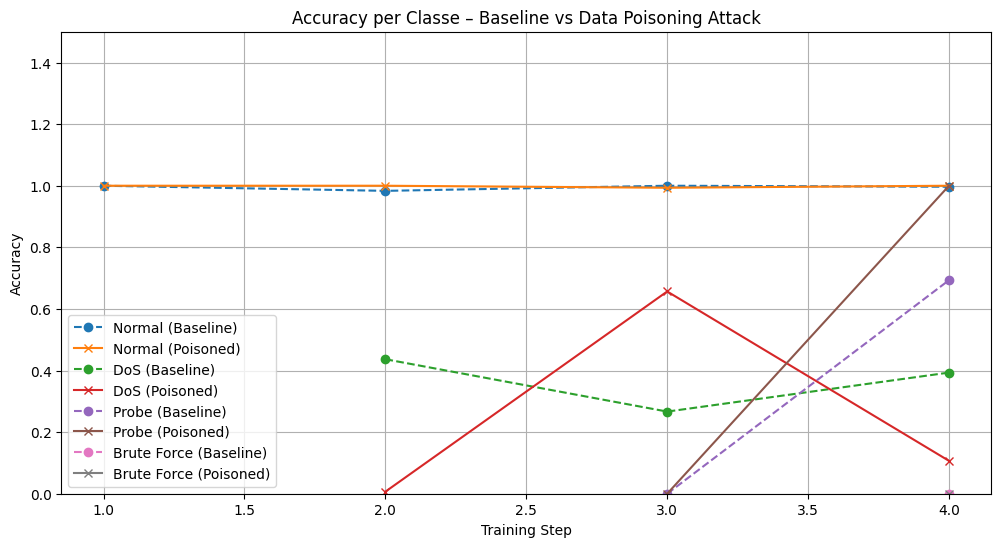

In [42]:
# BASELINE vs POISONED

import matplotlib.pyplot as plt

class_names = ["Normal", "DoS", "Probe", "Brute Force"]

plt.figure(figsize=(12, 6))

for c in range(num_classes):
    plt.plot(
        steps,
        baseline_metrics[c],
        marker='o',
        linestyle='--',
        label=f"{class_names[c]} (Baseline)"
    )
    plt.plot(
        steps,
        poisoned_metrics[c],
        marker='x',
        linestyle='-',
        label=f"{class_names[c]} (Poisoned)"
    )

plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title("Accuracy per Classe – Baseline vs Data Poisoning Attack")
plt.ylim(0, 1.5)
plt.legend()
plt.grid(True)
plt.show()


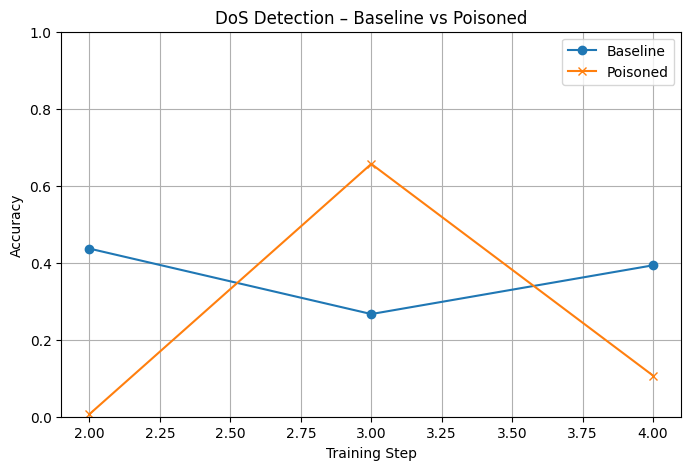

In [43]:
# Focus su DoS
critical_class = 1  # DoS

plt.figure(figsize=(8, 5))
plt.plot(
    steps,
    baseline_metrics[critical_class],
    marker='o',
    label="Baseline"
)
plt.plot(
    steps,
    poisoned_metrics[critical_class],
    marker='x',
    label="Poisoned"
)

plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title("DoS Detection – Baseline vs Poisoned")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()


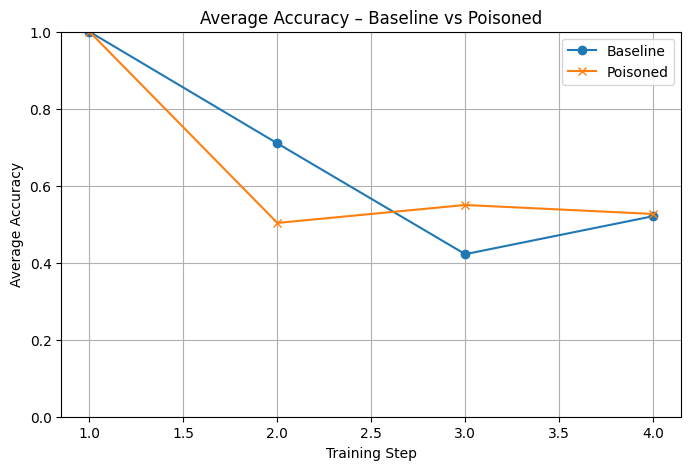

In [44]:
# Accuracy media globale
baseline_avg = [
    np.nanmean([baseline_metrics[c][i] for c in range(num_classes)])
    for i in range(len(steps))
]

poisoned_avg = [
    np.nanmean([poisoned_metrics[c][i] for c in range(num_classes)])
    for i in range(len(steps))
]

plt.figure(figsize=(8, 5))
plt.plot(steps, baseline_avg, marker='o', label="Baseline")
plt.plot(steps, poisoned_avg, marker='x', label="Poisoned")

plt.xlabel("Training Step")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy – Baseline vs Poisoned")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()
